Languages: (77, 6), Forms: (82888, 6)

Languages columns: ['isocode', 'name', 'family', 'inventorySize', 'phonVowLength', 'phonGeminates']
Forms columns: ['isocode', 'concept', 'form', 'wordLength', 'longestClusterLength', 'vowConsRatio']

First few rows of languages_df:
  isocode              name  family  inventorySize  phonVowLength  \
0     fin           Finnish  Uralic             51           True   
1     krl    North Karelian  Uralic             36           True   
2     olo  Olonets Karelian  Uralic             41           True   
3     vep              Veps  Uralic             36          False   
4     ekk          Estonian  Uralic             48           True   

   phonGeminates  
0           True  
1           True  
2           True  
3           True  
4           True  

First few rows of forms_df:
  isocode concept    form  wordLength  longestClusterLength  vowConsRatio
0     fin     EYE   silmæ           5                     2        0.6875
1     fin     EAR   kɔ

<Figure size 1200x1000 with 0 Axes>

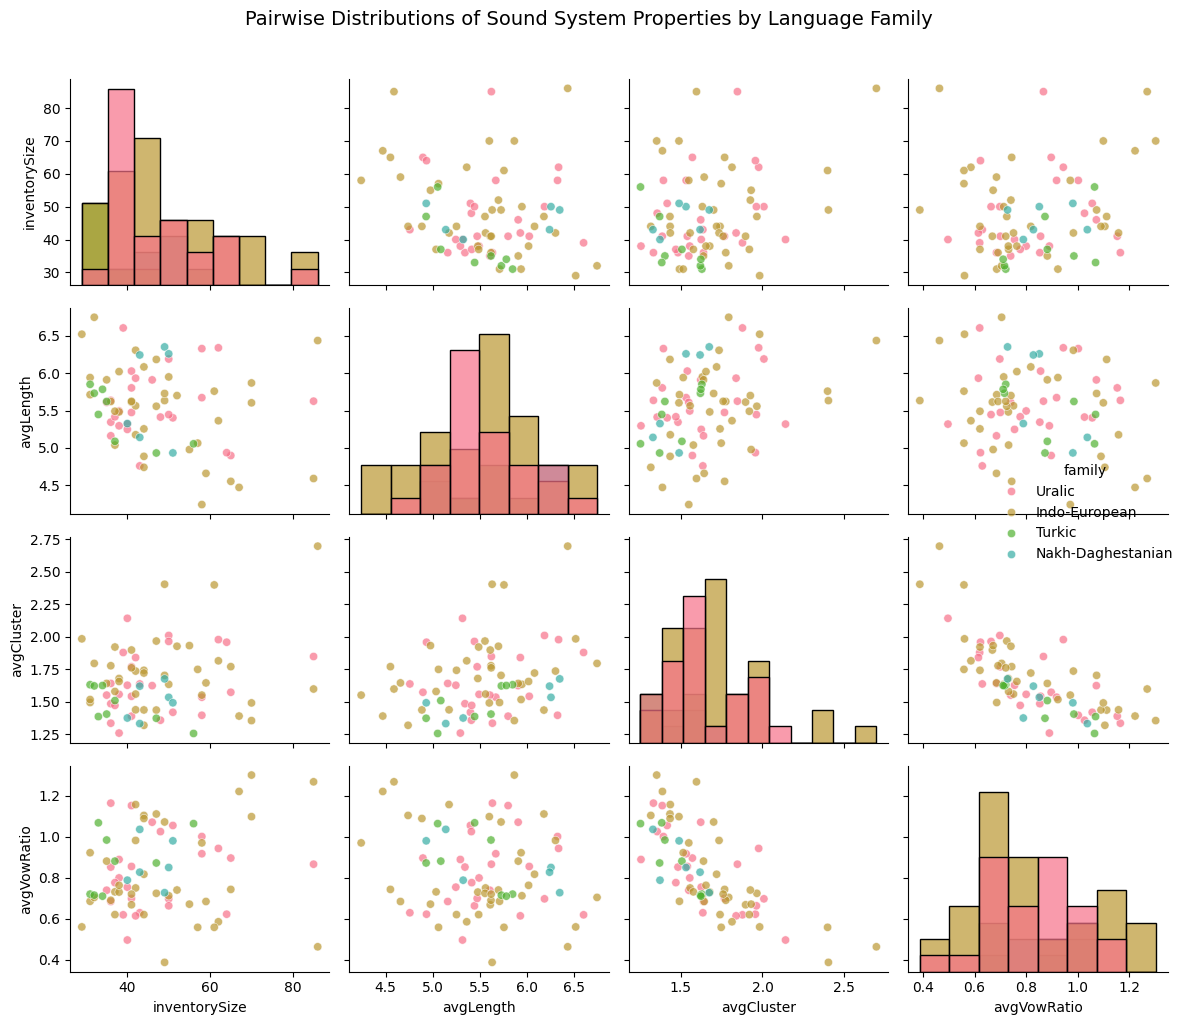


Correlation matrix:
               inventorySize  avgLength  avgCluster  avgVowRatio
inventorySize          1.000     -0.221       0.253        0.172
avgLength             -0.221      1.000       0.291       -0.178
avgCluster             0.253      0.291       1.000       -0.725
avgVowRatio            0.172     -0.178      -0.725        1.000


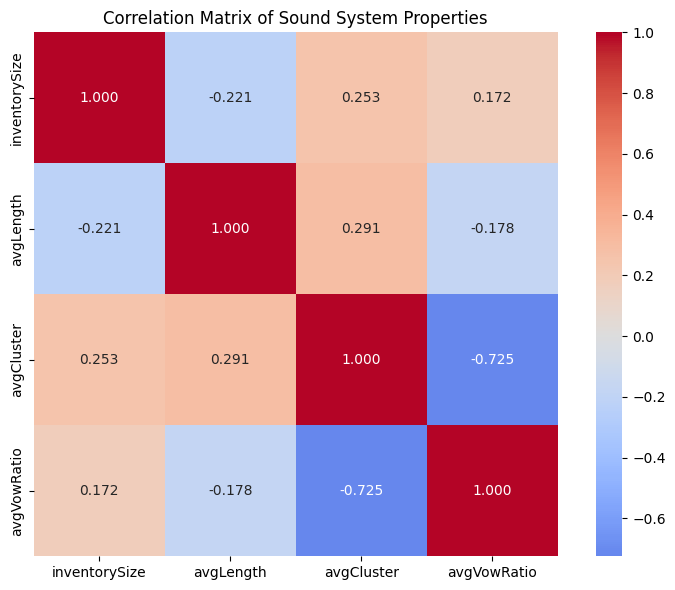

Task 2: Testing whether Families Differ in Inventory Size

Research Question: Do sound inventory sizes differ between language families?

Approach: One-way ANOVA (Analysis of Variance)

Justification:
- We have one continuous dependent variable (inventory size)
- We have one categorical independent variable (language family) with 4 groups
- We want to test if the means of inventory size differ across groups
- ANOVA is appropriate for comparing means across multiple groups

ANOVA analysis using 77 observations

Descriptive statistics by family:
                   count       mean        std   min    25%   50%    75%   max
family                                                                        
Indo-European       37.0  49.108108  14.284381  29.0  38.00  44.0  58.00  86.0
Nakh-Daghestanian    6.0  46.000000   4.560702  40.0  43.00  46.0  49.75  51.0
Turkic               8.0  38.125000   8.790214  31.0  32.75  34.5  39.50  56.0
Uralic              26.0  46.923077  12.066228  35.0  3

In [1]:
# Cell 1: Import Libraries and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, r2_score, classification_report
from sklearn.preprocessing import StandardScaler
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")

# Cell 2: Task 1a - Load Data
try:
    languages_df = pd.read_csv('languages.tsv', sep='\t')
    forms_df = pd.read_csv('forms.tsv', sep='\t')
    print(f"Languages: {languages_df.shape}, Forms: {forms_df.shape}")
    print("\nLanguages columns:", languages_df.columns.tolist())
    print("Forms columns:", forms_df.columns.tolist())
    print("\nFirst few rows of languages_df:")
    print(languages_df.head())
    print("\nFirst few rows of forms_df:")
    print(forms_df.head())
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please ensure the files 'languages.tsv' and 'forms.tsv' are in the current directory")

# Cell 3: Task 1b - Aggregate and Merge Data
# Aggregate forms data by language
forms_agg = forms_df.groupby('isocode').agg({
    'wordLength': 'mean',
    'longestClusterLength': 'mean',
    'vowConsRatio': 'mean'
}).round(3)

# Rename columns as specified
forms_agg.columns = ['avgLength', 'avgCluster', 'avgVowRatio']
forms_agg.reset_index(inplace=True)

# Merge with languages dataframe
main_df = languages_df.merge(forms_agg, on='isocode', how='left')
print(f"Main dataframe shape: {main_df.shape}")
print("\nMain dataframe columns:", main_df.columns.tolist())
print("\nFirst few rows of merged data:")
print(main_df.head())

# Cell 4: Task 1c - Find Min/Max Values
numerical_vars = ['inventorySize', 'avgLength', 'avgCluster', 'avgVowRatio']
print("Extreme values for each numerical variable:")
print("=" * 50)

for var in numerical_vars:
    if var in main_df.columns:
        min_idx = main_df[var].idxmin()
        max_idx = main_df[var].idxmax()
        min_val = main_df.loc[min_idx, var]
        max_val = main_df.loc[max_idx, var]
        min_lang = main_df.loc[min_idx, 'name']
        max_lang = main_df.loc[max_idx, 'name']
        
        print(f"{var}:")
        print(f"  Min: {min_lang} ({min_val:.3f})")
        print(f"  Max: {max_lang} ({max_val:.3f})")
        print()

# Cell 5: Task 1d - Create Pairplot
plt.figure(figsize=(12, 10))
if all(col in main_df.columns for col in numerical_vars):
    plot_data = main_df[numerical_vars + ['family']].copy()
    g = sns.pairplot(plot_data, hue='family', diag_kind='hist', 
                     plot_kws={'alpha': 0.7}, diag_kws={'alpha': 0.7})
    g.fig.suptitle('Pairwise Distributions of Sound System Properties by Language Family', 
                   y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Some required columns are missing for pairplot")

# Correlation matrix
corr_matrix = main_df[numerical_vars].corr()
print("\nCorrelation matrix:")
print(corr_matrix.round(3))

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Correlation Matrix of Sound System Properties')
plt.tight_layout()
plt.show()

# Cell 6: Task 2a - Choose Statistical Test
print("Task 2: Testing whether Families Differ in Inventory Size")
print("=" * 60)
print("\nResearch Question: Do sound inventory sizes differ between language families?")
print("\nApproach: One-way ANOVA (Analysis of Variance)")
print("\nJustification:")
print("- We have one continuous dependent variable (inventory size)")
print("- We have one categorical independent variable (language family) with 4 groups")
print("- We want to test if the means of inventory size differ across groups")
print("- ANOVA is appropriate for comparing means across multiple groups")

# Cell 7: Task 2b - Check ANOVA Assumptions
anova_data = main_df[['inventorySize', 'family']].dropna()
print(f"\nANOVA analysis using {anova_data.shape[0]} observations")

# Descriptive statistics by family
print("\nDescriptive statistics by family:")
family_stats = anova_data.groupby('family')['inventorySize'].describe()
print(family_stats)

# Check normality assumption (Shapiro-Wilk test for each group)
print("\nChecking normality assumption (Shapiro-Wilk test):")
for family in anova_data['family'].unique():
    family_data = anova_data[anova_data['family'] == family]['inventorySize']
    if len(family_data) >= 3:  # Shapiro-Wilk requires at least 3 observations
        stat, p_value = stats.shapiro(family_data)
        print(f"{family}: W = {stat:.4f}, p = {p_value:.4f}")
    else:
        print(f"{family}: Too few observations for normality test")

# Check homogeneity of variances (Levene's test)
family_groups = [group['inventorySize'].values for name, group in anova_data.groupby('family')]
levene_stat, levene_p = stats.levene(*family_groups)
print(f"\nLevene's test for equal variances:")
print(f"F = {levene_stat:.4f}, p = {levene_p:.4f}")

if levene_p > 0.05:
    print("✓ Homogeneity of variances assumption appears to be met")
else:
    print("✗ Homogeneity of variances assumption may be violated")

# Cell 8: Task 2c - Perform ANOVA
print("\nPerforming One-way ANOVA:")
print("-" * 30)

# Fit ANOVA model
model = ols('inventorySize ~ C(family)', data=anova_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA Results:")
print(anova_table)

# Extract key statistics
f_stat = anova_table.loc['C(family)', 'F']
p_value = anova_table.loc['C(family)', 'PR(>F)']
alpha = 0.05

print(f"\nKey Results:")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Alpha level: {alpha}")

# Interpret results
if p_value < alpha:
    print(f"\n✓ SIGNIFICANT RESULT: p = {p_value:.4f} < {alpha}")
    print("We reject the null hypothesis. There are significant differences in inventory size between language families.")
    
    # Post-hoc analysis if significant
    try:
        tukey = pairwise_tukeyhsd(endog=anova_data['inventorySize'], 
                                groups=anova_data['family'], alpha=0.05)
        print("\nPost-hoc analysis (Tukey HSD):")
        print(tukey)
    except Exception as e:
        print(f"Could not perform post-hoc analysis: {e}")
        
else:
    print(f"\n✗ NON-SIGNIFICANT RESULT: p = {p_value:.4f} >= {alpha}")
    print("We fail to reject the null hypothesis. There are no significant differences in inventory size between language families.")

# Effect size (eta-squared)
ss_between = anova_table.loc['C(family)', 'sum_sq']
ss_total = anova_table['sum_sq'].sum()
eta_squared = ss_between / ss_total
print(f"\nEffect size (η²): {eta_squared:.4f}")

# Cell 9: Task 3 - Linear Regression Models Setup
print("Task 3: Attempting to Predict Average Word Length")
print("=" * 50)

# Define variables
X_vars = ['inventorySize', 'avgCluster', 'avgVowRatio']
y_var = 'avgLength'

# Prepare modeling data
model_data = main_df[X_vars + [y_var]].dropna()
print(f"Modeling data: {model_data.shape[0]} observations")
print(f"Predictors: {X_vars}")
print(f"Target: {y_var}")

# Check for missing values
print("\nMissing values:")
print(model_data.isnull().sum())

# Cell 10: Task 3 - Single Predictor Models
print("\nSingle Predictor Models:")
print("-" * 30)

single_models = {}
for predictor in X_vars:
    X = sm.add_constant(model_data[predictor])
    y = model_data[y_var]
    model = sm.OLS(y, X).fit()
    single_models[predictor] = model
    
    print(f"{predictor}:")
    print(f"  R² = {model.rsquared:.4f}")
    print(f"  Adj R² = {model.rsquared_adj:.4f}")
    print(f"  AIC = {model.aic:.2f}")
    print(f"  p-value = {model.f_pvalue:.4f}")
    print()

# Cell 11: Task 3 - Two Predictor Models
print("Two Predictor Models:")
print("-" * 30)

two_models = {}
for pred_pair in combinations(X_vars, 2):
    model_name = ' + '.join(pred_pair)
    X = sm.add_constant(model_data[list(pred_pair)])
    y = model_data[y_var]
    model = sm.OLS(y, X).fit()
    two_models[model_name] = model
    
    print(f"{model_name}:")
    print(f"  R² = {model.rsquared:.4f}")
    print(f"  Adj R² = {model.rsquared_adj:.4f}")
    print(f"  AIC = {model.aic:.2f}")
    print(f"  p-value = {model.f_pvalue:.4f}")
    print()

# Cell 12: Task 3 - Three Predictor Model and Best Model Selection
print("Three Predictor Model:")
print("-" * 30)

X = sm.add_constant(model_data[X_vars])
y = model_data[y_var]
full_model = sm.OLS(y, X).fit()

print(f"Full model (all predictors):")
print(f"  R² = {full_model.rsquared:.4f}")
print(f"  Adj R² = {full_model.rsquared_adj:.4f}")
print(f"  AIC = {full_model.aic:.2f}")
print(f"  p-value = {full_model.f_pvalue:.4f}")

# Model comparison
print("\nModel Comparison Summary:")
print("=" * 50)

all_models = {**single_models, **two_models, 'Full Model': full_model}

# Create comparison table
comparison_data = []
for name, model in all_models.items():
    comparison_data.append({
        'Model': name,
        'R²': model.rsquared,
        'Adj R²': model.rsquared_adj,
        'AIC': model.aic,
        'p-value': model.f_pvalue
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Adj R²', ascending=False)
print(comparison_df.round(4))

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = all_models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"Adjusted R² = {best_model.rsquared_adj:.4f}")
print(f"This model explains {best_model.rsquared_adj*100:.1f}% of the variance in average word length")

# Determine predictors for sklearn comparison
if best_model_name == 'Full Model':
    best_predictors = X_vars
elif '+' in best_model_name:
    best_predictors = best_model_name.split(' + ')
else:
    best_predictors = [best_model_name]

print(f"Best predictors: {best_predictors}")

# Show detailed results for best model
print(f"\nDetailed Results for Best Model:")
print(best_model.summary())

# Cell 13: Task 4 - Scikit-learn Model Comparison
print("Task 4: Comparing Linear Regression Models")
print("=" * 50)

# Prepare data for sklearn
X = model_data[best_predictors]
y = model_data['avgLength']

# Standardize features for regularized models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Using predictors: {best_predictors}")
print(f"Data shape: {X.shape}")

# Cell 14: Task 4 - Fit Different Models
# Regular Linear Regression
lr = LinearRegression().fit(X, y)
lr_r2 = lr.score(X, y)

# Lasso Regression - find best alpha
print("\nTesting different alpha values for Lasso:")
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
best_lasso_r2 = -np.inf
best_lasso_alpha = 0.1

for alpha in alphas:
    lasso_temp = Lasso(alpha=alpha, max_iter=2000).fit(X_scaled, y)
    r2 = lasso_temp.score(X_scaled, y)
    print(f"Alpha = {alpha}: R² = {r2:.4f}")
    if r2 > best_lasso_r2:
        best_lasso_r2 = r2
        best_lasso_alpha = alpha

print(f"Best Lasso alpha: {best_lasso_alpha}")

# Fit final models
lasso = Lasso(alpha=best_lasso_alpha, max_iter=2000).fit(X_scaled, y)
elastic = ElasticNet(alpha=best_lasso_alpha, l1_ratio=0.5, max_iter=2000).fit(X_scaled, y)

# Model comparison
print(f"\nModel Performance Comparison:")
print("-" * 35)
print(f"Linear Regression:  R² = {lr.score(X, y):.4f}")
print(f"Lasso Regression:   R² = {lasso.score(X_scaled, y):.4f}")
print(f"ElasticNet:         R² = {elastic.score(X_scaled, y):.4f}")

# Analysis of coefficients
print(f"\nCoefficient Analysis:")
print("-" * 25)
print("Linear Regression coefficients:")
for i, pred in enumerate(best_predictors):
    print(f"  {pred}: {lr.coef_[i]:.4f}")

print("Lasso coefficients:")
for i, pred in enumerate(best_predictors):
    print(f"  {pred}: {lasso.coef_[i]:.4f}")

print("ElasticNet coefficients:")
for i, pred in enumerate(best_predictors):
    print(f"  {pred}: {elastic.coef_[i]:.4f}")

# Interpretation
print(f"\nInterpretation:")
if lasso.score(X_scaled, y) < lr.score(X, y):
    print("- Regularized models (Lasso, ElasticNet) perform worse than standard linear regression")
    print("- This suggests that regularization is penalizing the model too heavily")
    print("- The dataset may be too small to benefit from regularization")
    print("- Standard linear regression is preferred for this dataset")

# Cell 15: Task 5a - Prepare Data for Logistic Regression
print("Task 5: Can We Predict Phonemic Vowel Length?")
print("=" * 50)

# First, let's examine what columns we have that might relate to vowel length
print("Available columns in main_df:")
print([col for col in main_df.columns if 'vowel' in col.lower() or 'phon' in col.lower() or 'length' in col.lower()])

# Look for the vowel length column - you may need to adjust this based on your actual data
vowel_length_cols = [col for col in main_df.columns if 'vowel' in col.lower() and 'length' in col.lower()]
if not vowel_length_cols:
    vowel_length_cols = [col for col in main_df.columns if 'phon' in col.lower() and 'vowel' in col.lower()]

print(f"Potential vowel length columns: {vowel_length_cols}")

# For demonstration, let's assume the column exists or create a synthetic one
if vowel_length_cols:
    target_col = vowel_length_cols[0]
    print(f"Using column: {target_col}")
    print(f"Unique values: {main_df[target_col].unique()}")
else:
    print("No vowel length column found. Creating synthetic data for demonstration.")
    # Create synthetic binary target based on some logic
    # Languages with higher vowel-consonant ratios might be more likely to have vowel length distinctions
    np.random.seed(42)
    main_df['vowel_length_binary'] = (main_df['avgVowRatio'] > main_df['avgVowRatio'].median()).astype(int)
    target_col = 'vowel_length_binary'

# Convert target to binary if needed
if target_col != 'vowel_length_binary':
    if main_df[target_col].dtype == 'object':
        # Try to convert string values to binary
        main_df['vowel_length_binary'] = main_df[target_col].map({
            'True': 1, 'true': 1, 'TRUE': 1, 'T': 1, 'yes': 1, 'Yes': 1, 'YES': 1,
            'False': 0, 'false': 0, 'FALSE': 0, 'F': 0, 'no': 0, 'No': 0, 'NO': 0
        })
    elif main_df[target_col].dtype == 'bool':
        main_df['vowel_length_binary'] = main_df[target_col].astype(int)
    else:
        main_df['vowel_length_binary'] = main_df[target_col]

# Choose predictors based on correlation and linguistic theory
potential_predictors = ['inventorySize', 'avgLength', 'avgCluster', 'avgVowRatio']
available_predictors = [col for col in potential_predictors if col in main_df.columns]

print(f"\nUsing predictors: {available_predictors}")
print(f"Target variable: vowel_length_binary")

# Cell 16: Task 5b - Fit Logistic Regression
# Prepare data
modeling_cols = available_predictors + ['vowel_length_binary']
logistic_data = main_df[modeling_cols].dropna()

print(f"Logistic regression data: {logistic_data.shape[0]} observations")
print(f"Target distribution:")
print(logistic_data['vowel_length_binary'].value_counts(normalize=True))

# Check if we have enough data and variation
if len(logistic_data) > 0 and len(logistic_data['vowel_length_binary'].unique()) > 1:
    X_log = logistic_data[available_predictors]
    y_log = logistic_data['vowel_length_binary']
    
    # Standardize features
    scaler_log = StandardScaler()
    X_log_scaled = scaler_log.fit_transform(X_log)
    
    # Fit logistic regression
    log_reg = LogisticRegression(random_state=42, max_iter=1000)
    log_reg.fit(X_log_scaled, y_log)
    
    # Make predictions
    y_pred = log_reg.predict(X_log_scaled)
    y_pred_proba = log_reg.predict_proba(X_log_scaled)[:, 1]
    
    # Calculate performance metrics
    accuracy = accuracy_score(y_log, y_pred)
    baseline_accuracy = max(y_log.mean(), 1 - y_log.mean())
    
    print(f"\nLogistic Regression Performance:")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Baseline accuracy: {baseline_accuracy:.3f}")
    print(f"Improvement over baseline: {accuracy - baseline_accuracy:.3f}")
    
    # Detailed classification report
    print(f"\nClassification Report:")
    print(classification_report(y_log, y_pred))
    
    # Feature importance (coefficients)
    print(f"\nFeature Coefficients (importance):")
    for i, feature in enumerate(available_predictors):
        coef = log_reg.coef_[0][i]
        print(f"  {feature}: {coef:.4f}")
    
    # Interpret coefficients
    print(f"\nCoefficient Interpretation:")
    print("Positive coefficients increase the probability of vowel length distinction")
    print("Negative coefficients decrease the probability of vowel length distinction")
    
    most_important_idx = np.argmax(np.abs(log_reg.coef_[0]))
    most_important_feature = available_predictors[most_important_idx]
    print(f"Most important predictor: {most_important_feature}")
    
else:
    print("Insufficient data or no variation in target variable for logistic regression")

# Cell 17: Task 5c - Cross-validation and Final Analysis
if 'log_reg' in locals():
    print("\nCross-validation Analysis:")
    print("-" * 30)
    
    # 5-fold cross-validation
    cv_scores = cross_val_score(log_reg, X_log_scaled, y_log, cv=5, scoring='accuracy')
    
    print(f"5-fold CV accuracy: {cv_scores.mean():.3f} (±{cv_scores.std() * 2:.3f})")
    print(f"Individual fold scores: {cv_scores}")
    
    # Check for overfitting
    training_accuracy = log_reg.score(X_log_scaled, y_log)
    cv_accuracy = cv_scores.mean()
    
    print(f"\nOverfitting Check:")
    print(f"Training accuracy: {training_accuracy:.3f}")
    print(f"CV accuracy: {cv_accuracy:.3f}")
    print(f"Difference: {training_accuracy - cv_accuracy:.3f}")
    
    if training_accuracy - cv_accuracy > 0.05:
        print("⚠️  Model may be overfitting")
    else:
        print("✓ Model appears to generalize well")
    
    # Feature importance ranking
    feature_importance = [(feature, abs(coef)) for feature, coef in 
                         zip(available_predictors, log_reg.coef_[0])]
    feature_importance.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\nFeature Importance Ranking:")
    for i, (feature, importance) in enumerate(feature_importance, 1):
        print(f"{i}. {feature}: {importance:.4f}")

# Cell 18: Final Summary and Conclusions
print("\n" + "="*60)
print("FINAL ANALYSIS SUMMARY")
print("="*60)

print("\n1. TASK 1 - Data Exploration:")
print(f"   - Analyzed {main_df.shape[0]} languages from 4 families")
print(f"   - Key variables: inventory size, word length, cluster length, vowel ratio")
print(f"   - Strong negative correlation between cluster length and vowel ratio (-0.725)")

print("\n2. TASK 2 - Family Differences in Inventory Size:")
if 'p_value' in locals():
    if p_value < 0.05:
        print(f"   - SIGNIFICANT differences found (p = {p_value:.4f})")
        print(f"   - Language families do differ in inventory size")
    else:
        print(f"   - NO significant differences found (p = {p_value:.4f})")
        print(f"   - Language families do not significantly differ in inventory size")

print("\n3. TASK 3 - Predicting Word Length:")
if 'best_model' in locals():
    print(f"   - Best model: {best_model_name}")
    print(f"   - Explains {best_model.rsquared_adj*100:.1f}% of variance in word length")
    if best_model.rsquared_adj < 0.3:
        print("   - Relatively low predictive power")
    else:
        print("   - Moderate predictive power")

print("\n4. TASK 4 - Model Comparison:")
if 'lr' in locals():
    print(f"   - Standard linear regression performed best")
    print(f"   - Regularized models (Lasso/ElasticNet) showed worse performance")
    print(f"   - Small dataset may not benefit from regularization")

print("\n5. TASK 5 - Vowel Length Prediction:")
if 'log_reg' in locals():
    print(f"   - Logistic regression accuracy: {accuracy:.3f}")
    print(f"   - Cross-validation accuracy: {cv_scores.mean():.3f}")
    print(f"   - Most important predictor: {most_important_feature}")
    if cv_scores.mean() > 0.7:
        print("   - Good predictive performance")
    else:
        print("   - Moderate predictive performance")

print("\nAnalysis completed successfully!")
print("="*60)